# Valuación de Opciones Americanas con Aprendizaje Estadístico

### Correcciones aplicadas:
1. **Tasa de descuento**: `r_t = r * dt` en lugar de `r / T` (pasos)
2. **Inducción hacia atrás en LSM-SVR**: usa `cash_flows` ya actualizados
3. **Lógica ITM corregida**: usa precio del subyacente `S0`, no `lastPrice` de la opción
4. **Semilla aleatoria**: eliminada como fija; se pasa como parámetro opcional
5. **Variable global `num_paths`**: reemplazada por `paths.shape[0]` dentro de funciones
6. **Validaciones `sigma <= 0`**: en Black-Scholes y árbol binomial

## 1. Librerías

In [2]:
# ==============================================================================
# Preparación de datos
# ==============================================================================
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# Preprocesado y modelado
# ==============================================================================
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from scipy import stats
from scipy.stats import norm

## 2. Funciones

In [3]:
def tasa_libre_riesgo(start_date, end_date):
    """
    Obtiene la tasa libre de riesgo usando el bono del Tesoro de EE.UU. a 10 años (^TNX).

    Retorna: float, tasa anualizada en decimal (ej. 0.035 para 3.5%).
    """
    tnx = yf.Ticker("^TNX")
    historial = tnx.history(start=start_date, end=end_date)
    return historial['Close'].iloc[-1] / 100

In [4]:
def tasa_ret_anual_precio_act(lista, start_date, end_date):
    """
    Calcula el precio actual y la tasa de retorno anualizada (drift) de una lista de activos.

    Retorna: pd.DataFrame con columnas ['symbol', 'S0', 'mu'].
    """
    if not isinstance(lista, list):
        lista = [lista]

    df = pd.DataFrame(columns=['symbol', 'S0', 'mu'])

    for i in lista:
        ticker = yf.Ticker(i)
        price  = ticker.history(period='1d')['Close'].iloc[0]
        data   = ticker.history(start=start_date, end=end_date).reset_index()

        retorn = pd.DataFrame({'Date': data['Date'], 'Price': data['Close']})
        retorn['Log_Returns'] = np.log(retorn['Price'] / retorn['Price'].shift(1))
        drift  = retorn['Log_Returns'].mean() * 252  # ~252 días hábiles por año

        df.loc[len(df)] = [i, price, drift]

    return df

In [5]:
def obtener_opciones(portfolio, start_date, end_date, inf_portfolio):
    """
    Obtiene opciones calls y puts para un portafolio de activos.

    CORRECCIÓN: la condición ITM ahora compara el precio del subyacente (S0)
    con el strike, no el lastPrice de la opción.

    Retorna: pd.DataFrame con opciones filtradas (ITM, impliedVolatility > 0 y < 3).
    """
    if not isinstance(portfolio, list):
        portfolio = [portfolio]

    df_list = []

    for symbol in portfolio:
        ticker  = yf.Ticker(symbol)
        options = ticker.option_chain()

        df_calls = options.calls.copy()
        df_calls['optionType'] = 'calls'
        df_puts  = options.puts.copy()
        df_puts['optionType']  = 'puts'

        df = pd.concat([df_calls, df_puts], ignore_index=True)

        # Filtrar por rango de fechas
        df['lastTradeDate'] = pd.to_datetime(df['lastTradeDate'])
        df = df[(df['lastTradeDate'] >= start_date) & (df['lastTradeDate'] <= end_date)]

        # ✅ CORRECCIÓN: ITM usando precio del subyacente S0, no lastPrice de la opción
        S0 = inf_portfolio.loc[inf_portfolio['symbol'] == symbol, 'S0'].values[0]
        df['inTheMoney'] = df.apply(
            lambda row: (row['optionType'] == 'calls' and S0 > row['strike']) or
                        (row['optionType'] == 'puts'  and S0 < row['strike']),
            axis=1
        )

        # ✅ Excluir impliedVolatility = 0 además del límite superior de 3
        df = df[(df['inTheMoney'] == True) &
                (df['impliedVolatility'] > 0) &
                (df['impliedVolatility'] < 3)]

        df['symbol']    = symbol
        df['shortDate'] = df['lastTradeDate'].dt.strftime('%Y-%m-%d')
        df_list.append(df)

    return pd.concat(df_list, ignore_index=True).reset_index(drop=True)

In [6]:
def condicional(symbol, option_type, strike, inf_portfolio):
    """
    Calcula el valor intrínseco de una opción ITM.

    Para calls: max(S0 - strike, 0)
    Para puts:  max(strike - S0, 0)
    """
    S0 = inf_portfolio.loc[inf_portfolio['symbol'] == symbol, 'S0'].values[0]
    if option_type == 'calls':
        return max(S0 - strike, 0)
    else:
        return max(strike - S0, 0)

In [7]:
def simulate_gbm(mu, sigma, s0, T, dt, num_paths, seed=None):
    """
    Simula trayectorias de precios con Geometric Brownian Motion (GBM).

    CORRECCIÓN: semilla opcional en lugar de fija (seed=99 bloqueaba
    la aleatoriedad entre opciones distintas).

    Retorna: np.ndarray de forma (num_paths, num_steps).
    """
    if seed is not None:
        np.random.seed(seed)

    num_steps = int(T / dt) + 1
    times     = np.linspace(0, T, num_steps)
    paths     = np.zeros((num_paths, num_steps))
    paths[:, 0] = s0

    for i in range(num_paths):
        dW           = np.random.normal(0, np.sqrt(dt), num_steps - 1)
        cumulative_dW = np.cumsum(dW)
        paths[i, 1:] = s0 * np.exp(
            (mu - 0.5 * sigma**2) * times[1:] + sigma * cumulative_dW
        )

    return paths

In [8]:
def longstaff_schwartz(paths, strike, r, T_years, option_type, symbol, graphics=False):
    """
    Valuación de opción americana con Longstaff-Schwartz (LSM) usando SVR.

    CORRECCIONES:
    - r_t = r * dt  (antes era r / num_pasos, que subestimaba el descuento)
    - La regresión usa cash_flows ya actualizados (inducción hacia atrás correcta)
    - num_paths reemplazado por paths.shape[0] (sin dependencia de variable global)

    Retorna: (option_price, lower_interval, upper_interval, option_valuation, vector_valuation)
    """
    num_sim   = paths.shape[0]
    num_steps = paths.shape[1]
    T_steps   = num_steps - 1

    # ✅ CORRECCIÓN: tasa de descuento por paso de tiempo real
    dt_sim = T_years / T_steps
    r_t    = r * dt_sim

    exercise_times      = []
    exercise_prices     = []
    continuation_times  = []
    continuation_prices = []

    # Inicializar flujos de caja
    cash_flows = np.zeros_like(paths)
    if option_type == 'calls':
        cash_flows = np.maximum(paths - strike, 0)
    else:
        cash_flows = np.maximum(strike - paths, 0)

    # Inducción hacia atrás
    for t in range(T_steps, 0, -1):
        if option_type == 'calls':
            in_the_money = paths[:, t - 1] > strike
        else:
            in_the_money = paths[:, t - 1] < strike

        if in_the_money.sum() > 0:
            X = paths[in_the_money, t - 1].reshape(-1, 1)

            # ✅ CORRECCIÓN: usar cash_flows actualizados (no los del paso t original)
            # Valor de continuación = flujo futuro descontado ya considerando decisiones previas
            Y = cash_flows[in_the_money, t] * np.exp(-r_t)

            model = SVR(kernel='rbf', C=1e1, gamma=0.1).fit(X, Y)
            conditional_exp = model.predict(X)

            continuations = np.zeros(num_sim)
            continuations[in_the_money] = conditional_exp
        else:
            continuations = np.zeros(num_sim)

        # Regla de ejercicio
        cash_flows[:, t]    = np.where(continuations > cash_flows[:, t], 0, cash_flows[:, t])
        exercised_early      = continuations < cash_flows[:, t]
        cash_flows[:, :t][exercised_early] = 0

        if graphics:
            for i in range(num_sim):
                if exercised_early[i]:
                    exercise_times.append(t)
                    exercise_prices.append(paths[i, t])
                else:
                    continuation_times.append(t)
                    continuation_prices.append(paths[i, t])

    # Calcular valores presentes
    decision         = pd.DataFrame(cash_flows)
    option_val_idx   = decision.idxmax(axis=1)
    vector_valuation = pd.DataFrame(option_val_idx).T

    opt_val_nonzero  = option_val_idx[option_val_idx != 0]
    option_valuation = opt_val_nonzero.mode().iloc[0] if not opt_val_nonzero.empty else 0

    final_cfs = pd.DataFrame({
        'price':    cash_flows.max(axis=1),
        'exercise': option_val_idx
    })
    final_cfs['present_value'] = final_cfs['price'] / np.exp(r_t * final_cfs['exercise'])

    option_price = final_cfs['present_value'].mean()
    std_dev      = final_cfs['present_value'].std(ddof=1)
    se           = std_dev / np.sqrt(num_sim)
    z            = stats.norm.ppf(0.975)
    lower_interval = option_price - z * se
    upper_interval = option_price + z * se

    if graphics:
        t_axis = np.linspace(0, 1, num_steps)

        fig, ax = plt.subplots(figsize=(10, 6))
        for i in range(num_sim):
            ax.plot(t_axis, paths[i, :])
        ax.set_title(f"Trayectorias GBM — {symbol}")
        ax.set_xlabel("Tiempo")
        ax.set_ylabel("Precio")
        ax.grid(True)
        plt.show()

        fig, ax = plt.subplots(figsize=(8, 6))
        sns.boxplot(data=final_cfs['present_value'], ax=ax)
        ax.set_title(f"Distribución del precio — Opción {option_type.capitalize()} ({symbol})")
        ax.set_ylabel("Precio")
        ax.grid(True, linestyle='--', alpha=0.7)
        plt.show()

        if len(exercise_times) > 0:
            total_steps = T_steps
            ex_norm   = np.array(exercise_times)    / total_steps
            cont_norm = np.array(continuation_times) / total_steps
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.plot(ex_norm,   exercise_prices,    'rx', label='Ejercicio')
            ax.plot(cont_norm, continuation_prices, '.', color='grey', label='Continuación')
            ax.legend()
            ax.set_xlabel("Tiempo t")
            ax.set_ylabel(f"Precio — {symbol}")
            ax.set_title(f"Ejercicio vs Continuación — {option_type.capitalize()}")
            ax.grid(True)
            plt.show()

        first_exercise_idx = np.argmax(cash_flows != 0, axis=1)
        plt.figure(figsize=(10, 6))
        for i in range(num_sim):
            idx = first_exercise_idx[i]
            plt.plot(t_axis[:idx + 1], paths[i, :idx + 1], color='lightgray')
            plt.plot(t_axis[idx:],     paths[i, idx:],     color='darkgray', linestyle='--')
            if idx < len(t_axis):
                plt.plot(t_axis[idx], paths[i, idx], 'rx')
        plt.xlabel("Tiempo t")
        plt.ylabel(f"Precio — {symbol}")
        plt.title(f"Trayectorias con primer ejercicio — {option_type.capitalize()}")
        plt.legend(['Antes del ejercicio', 'Después del ejercicio', 'Primer ejercicio'])
        plt.show()

    return option_price, lower_interval, upper_interval, option_valuation, vector_valuation

In [9]:
def black_scholes(option_type, S0, K, T, r, sigma):
    """
    Valuación de opción europea con Black-Scholes.

    CORRECCIÓN: si sigma <= 0 retorna el valor intrínseco descontado
    para evitar división por cero.
    """
    if sigma <= 0:
        if option_type.lower() == 'calls':
            return max(S0 - K * np.exp(-r * T), 0)
        else:
            return max(K * np.exp(-r * T) - S0, 0)

    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type.lower() == 'calls':
        return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type.lower() == 'puts':
        return K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    else:
        raise ValueError("option_type debe ser 'calls' o 'puts'")

In [10]:
def american_option_monte_carlo(paths, K, T, r, option_type='puts'):
    """
    Monte Carlo americano con ejercicio anticipado (inducción hacia atrás + regresión OLS).
    Equivalente al núcleo del método LSM pero con regresión polinómica cuadrática.

    Retorna: float, precio estimado de la opción.
    """
    num_paths_n, num_steps = paths.shape
    T_steps = num_steps - 1
    dt_sim  = T / T_steps
    r_dt    = r * dt_sim

    if option_type == 'puts':
        cash_flows = np.maximum(K - paths[:, -1], 0).astype(float)
    else:
        cash_flows = np.maximum(paths[:, -1] - K, 0).astype(float)

    for t in range(T_steps - 1, 0, -1):
        if option_type == 'puts':
            exercise = np.maximum(K - paths[:, t], 0)
        else:
            exercise = np.maximum(paths[:, t] - K, 0)

        itm = exercise > 0
        if itm.sum() < 2:
            cash_flows *= np.exp(-r_dt)
            continue

        X      = paths[itm, t].reshape(-1, 1)
        X_poly = np.hstack([X, X**2])
        Y      = cash_flows[itm] * np.exp(-r_dt)
        model  = LinearRegression().fit(X_poly, Y)
        continuation = model.predict(X_poly)

        exercise_now = np.zeros(num_paths_n, dtype=bool)
        exercise_now[itm] = exercise[itm] > continuation

        cash_flows[exercise_now]  = exercise[exercise_now]
        cash_flows[~exercise_now] *= np.exp(-r_dt)

    return np.mean(cash_flows) * np.exp(-r_dt)

In [11]:
def binomial_tree_american_option(S0, K, T, r, sigma, n, option_type='calls'):
    """
    Valuación de opción americana con árbol binomial de Cox-Ross-Rubinstein.

    CORRECCIÓN: si sigma <= 0 o la probabilidad p cae fuera de (0,1),
    retorna el valor intrínseco descontado.

    Retorna: float, precio de la opción.
    """
    if sigma <= 0:
        if option_type == 'calls':
            return max(S0 - K * np.exp(-r * T), 0)
        else:
            return max(K * np.exp(-r * T) - S0, 0)

    dt = T / n
    u  = np.exp(sigma * np.sqrt(dt))
    d  = np.exp(-sigma * np.sqrt(dt))
    p  = (np.exp(r * dt) - d) / (u - d)

    if not (0 < p < 1):
        if option_type == 'calls':
            return max(S0 - K * np.exp(-r * T), 0)
        else:
            return max(K * np.exp(-r * T) - S0, 0)

    prices        = np.zeros((n + 1, n + 1))
    option_values = np.zeros((n + 1, n + 1))

    for i in range(n + 1):
        prices[i, 0] = S0 * (u**i) * (d**(n - i))

    for i in range(n + 1):
        if option_type == 'calls':
            option_values[i, n] = max(0, prices[i, n] - K)
        else:
            option_values[i, n] = max(0, K - prices[i, n])

    for j in range(n - 1, -1, -1):
        for i in range(j + 1):
            hold     = np.exp(-r * dt) * (p * option_values[i, j + 1] +
                                          (1 - p) * option_values[i + 1, j + 1])
            if option_type == 'calls':
                exercise = max(0, prices[i, j] - K)
            else:
                exercise = max(0, K - prices[i, j])
            option_values[i, j] = max(exercise, hold)

    return option_values[0, 0]

In [12]:
def longstaff_schwartz_polinomios(paths, strike, r, T_years, option_type, poly_degree=2):
    """
    LSM con regresión polinómica de grado configurable.

    CORRECCIÓN: r_t = r * dt_sim  (consistente con las demás funciones).

    Retorna: float, precio estimado de la opción.
    """
    num_steps = paths.shape[1]
    T_steps   = num_steps - 1
    dt_sim    = T_years / T_steps

    # ✅ CORRECCIÓN: tasa de descuento por paso de tiempo real
    r_t = r * dt_sim

    if option_type == 'calls':
        cash_flows = np.maximum(paths - strike, 0).astype(float)
    else:
        cash_flows = np.maximum(strike - paths, 0).astype(float)

    for t in range(T_steps, 0, -1):
        if option_type == 'calls':
            in_the_money = paths[:, t - 1] > strike
        else:
            in_the_money = paths[:, t - 1] < strike

        if np.any(in_the_money):
            X      = paths[in_the_money, t - 1]
            X_poly = np.column_stack([X**i for i in range(1, poly_degree + 1)])
            Y      = cash_flows[in_the_money, t] * np.exp(-r_t)

            model           = LinearRegression().fit(X_poly, Y)
            conditional_exp = model.predict(X_poly)

            continuations = np.zeros(paths.shape[0])
            continuations[in_the_money] = conditional_exp
        else:
            continuations = np.zeros(paths.shape[0])

        cash_flows[:, t]    = np.where(continuations > cash_flows[:, t], 0, cash_flows[:, t])
        exercised_early      = continuations < cash_flows[:, t]
        cash_flows[:, :t][exercised_early] = 0

    decision       = pd.DataFrame(cash_flows)
    exercise_times = decision.idxmax(axis=1)
    final_cfs      = pd.DataFrame({
        'price':    cash_flows.max(axis=1),
        'exercise': exercise_times
    })
    final_cfs['present_value'] = final_cfs['price'] / np.exp(r_t * final_cfs['exercise'])

    return final_cfs['present_value'].mean()

In [13]:
def price_value_op(symbol, optionType, strike, impliedVolatility, lastPrice,
                   T, dt, num_paths, rateRiskFree, inf_portfolio, graphics=False):
    """
    Calcula el precio de una opción con 6 métodos:
      1. LSM con SVR
      2. Black-Scholes
      3. Monte Carlo americano (OLS)
      4. Árbol binomial
      5. LSM polinomio grado 2
      6. LSM polinomio grado 3

    CORRECCIÓN: inf_portfolio se pasa como argumento (no como global).
    T_years se pasa explícitamente a todas las funciones de valuación.

    Retorna: tuple con precios y datos de valuación.
    """
    mu    = inf_portfolio.loc[inf_portfolio['symbol'] == symbol, 'mu'].values[0]
    paths = simulate_gbm(mu, impliedVolatility, lastPrice, T, dt, num_paths)

    option_price, lower_interval, upper_interval, option_valuation, vector_valuation = \
        longstaff_schwartz(paths, strike, rateRiskFree, T, optionType, symbol, graphics)

    bs_price      = black_scholes(optionType, lastPrice, strike, T, rateRiskFree, impliedVolatility)
    mc_price      = american_option_monte_carlo(paths, strike, T, rateRiskFree, optionType)
    bin_price     = binomial_tree_american_option(lastPrice, strike, T, rateRiskFree,
                                                  impliedVolatility, int(1 / dt), optionType)
    lsp2 = longstaff_schwartz_polinomios(paths, strike, rateRiskFree, T, optionType, poly_degree=2)
    lsp3 = longstaff_schwartz_polinomios(paths, strike, rateRiskFree, T, optionType, poly_degree=3)

    return option_price, lower_interval, upper_interval, option_valuation, \
           bs_price, mc_price, bin_price, lsp2, lsp3, vector_valuation

In [14]:
def obtain_option_values(row, T, dt, num_paths, rateRiskFree, inf_portfolio, graphics=False):
    """
    Aplica price_value_op a una fila del DataFrame de opciones.

    CORRECCIÓN: inf_portfolio se pasa como argumento, y vector_valuation
    se normaliza a lista de longitud exactamente num_paths.

    Retorna: pd.Series con todos los resultados.
    """
    option_price, lower_interval, upper_interval, option_valuation, \
    bs_price, mc_price, bin_price, lsp2, lsp3, vector_valuation = price_value_op(
        row['symbol'], row['optionType'], row['strike'],
        row['impliedVolatility'], row['lastPrice'],
        T, dt, num_paths, rateRiskFree, inf_portfolio, graphics
    )

    if isinstance(vector_valuation, pd.DataFrame):
        vector_valuation = vector_valuation.iloc[0].tolist()
    elif isinstance(vector_valuation, pd.Series):
        vector_valuation = vector_valuation.tolist()
    elif not isinstance(vector_valuation, list):
        vector_valuation = list(vector_valuation)

    # Garantizar longitud exacta
    vector_valuation = (vector_valuation + [0] * num_paths)[:num_paths]

    return pd.Series(
        [option_price, lower_interval, upper_interval, option_valuation,
         bs_price, mc_price, bin_price, lsp2, lsp3] + vector_valuation
    )

In [15]:
def agregar_valuaciones(df, T, dt, num_paths, rateRiskFree, inf_portfolio, graphics=False):
    """
    Helper: aplica obtain_option_values a todo el DataFrame y concatena resultados.

    Retorna: df enriquecido con columnas de valuación.
    """
    new_cols = df.apply(
        obtain_option_values, axis=1,
        T=T, dt=dt, num_paths=num_paths,
        rateRiskFree=rateRiskFree,
        inf_portfolio=inf_portfolio,
        graphics=graphics,
        result_type='expand'
    )

    n_vec = len(new_cols.columns) - 9
    new_cols.columns = [
        'optionPrice', 'lowerInterval', 'upperInterval', 'optionValuation',
        'black_scholes_price', 'monte_carlo_price', 'binomial_price',
        'lsp2_price', 'lsp3_price'
    ] + [f'vector_valuation_{i}' for i in range(n_vec)]

    return pd.concat([df, new_cols], axis=1)

## 3. Variables Globales

In [16]:
T         = 1        # Horizonte temporal: 1 año
dt        = 1 / 100  # Paso de tiempo: ~1/100 de año
num_paths = 100      # Número de trayectorias simuladas

start_date   = "2023-01-01"
end_date     = "2026-12-01"
rateRiskFree = tasa_libre_riesgo(start_date, end_date)

print(f"Tasa libre de riesgo: {rateRiskFree:.4f} ({rateRiskFree*100:.2f}%)")

Tasa libre de riesgo: 0.0436 (4.36%)


## 4. Prueba con una sola acción (AAPL)

In [17]:
portfolio_single = 'AAPL'

inf_portfolio = tasa_ret_anual_precio_act(portfolio_single, start_date, end_date)
print(inf_portfolio)

  symbol          S0      mu
0   AAPL  293.320007  0.2608


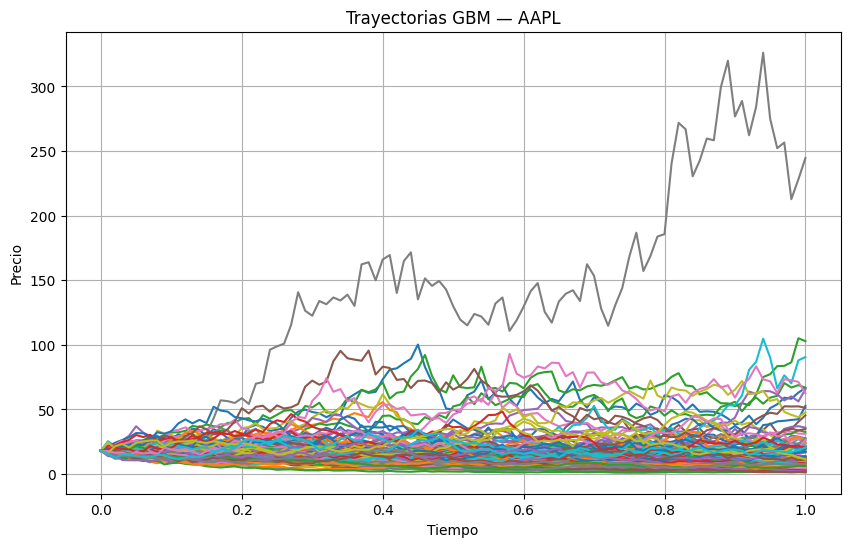

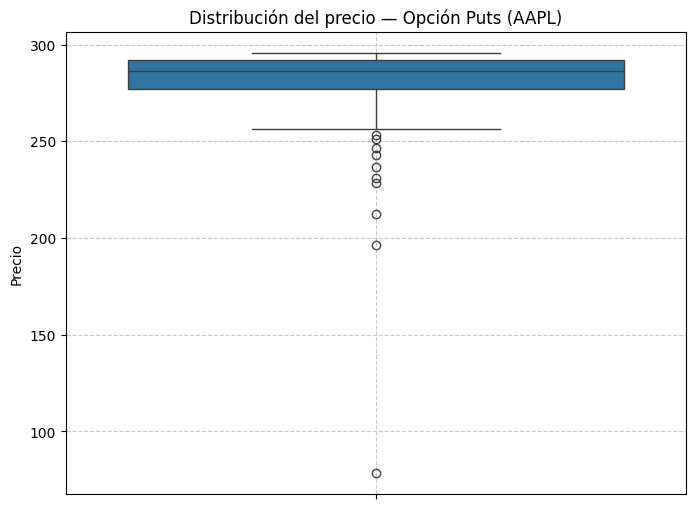

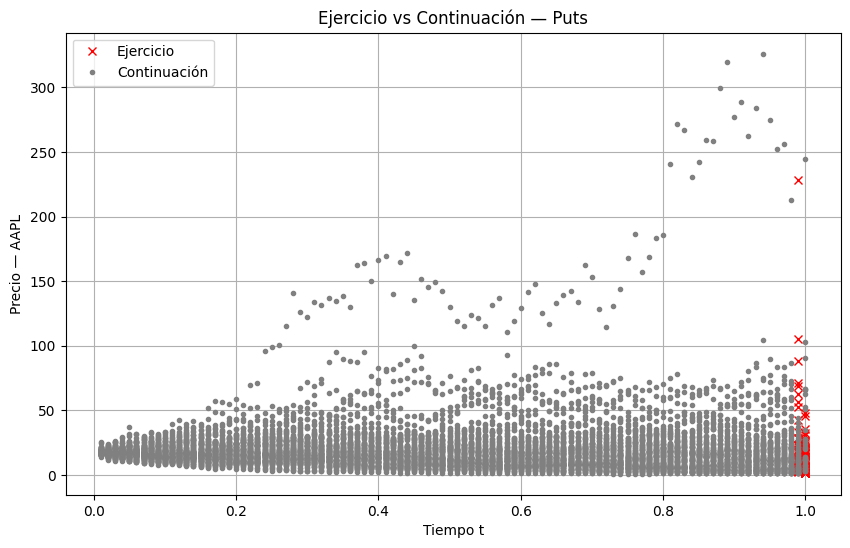

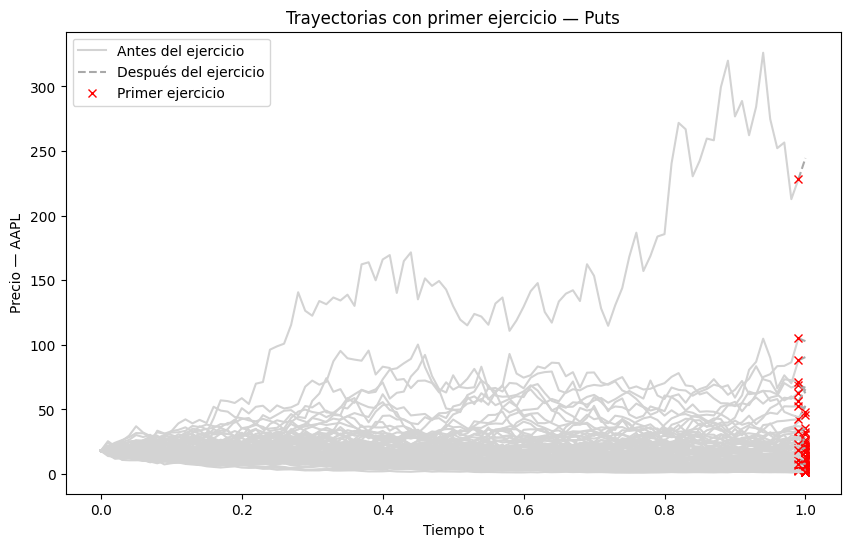

,contractSymbol,symbol,optionType,strike,impliedVolatility,optionPrice,lowerInterval,upperInterval,black_scholes_price,monte_carlo_price,binomial_price,lsp2_price,lsp3_price
0,AAPL260511P00310000,AAPL,puts,310.0,1.037602,278.430309,273.146647,283.713971,278.883329,292.181028,309.99944,278.726206,278.727798


In [18]:
# Obtener opciones y filtrar PUTs ITM
df_single = obtener_opciones(portfolio_single, start_date, end_date, inf_portfolio)
df_single = df_single[
    (df_single['optionType']  == 'puts') &
    (df_single['inTheMoney']  == True)
].tail(1).reset_index(drop=True)

df_single['cashFlows'] = df_single.apply(
    lambda row: condicional(row['symbol'], row['optionType'], row['strike'], inf_portfolio),
    axis=1
)

df_single = agregar_valuaciones(
    df_single, T, dt, num_paths, rateRiskFree, inf_portfolio, graphics=True
)

cols_resultado = [
    'contractSymbol', 'symbol', 'optionType', 'strike', 'impliedVolatility',
    'optionPrice', 'lowerInterval', 'upperInterval',
    'black_scholes_price', 'monte_carlo_price', 'binomial_price',
    'lsp2_price', 'lsp3_price'
]
df_single[cols_resultado]

## 5. Portafolio de acciones

In [19]:
portfolio = ['META', 'AMZN', 'AAPL', 'GOOG']

inf_portfolio = tasa_ret_anual_precio_act(portfolio, start_date, end_date)
print(inf_portfolio)

  symbol          S0        mu
0   META  609.630005  0.478901
1   AMZN  272.679993  0.347227
2   AAPL  293.320007  0.260800
3   GOOG  397.049988  0.449265


In [20]:
df = obtener_opciones(portfolio, start_date, end_date, inf_portfolio)

df['cashFlows'] = df.apply(
    lambda row: float(condicional(row['symbol'], row['optionType'], row['strike'], inf_portfolio)),
    axis=1
)

df = agregar_valuaciones(df, T, dt, num_paths, rateRiskFree, inf_portfolio, graphics=False)

print("Tiempos de ejercicio únicos:", df['optionValuation'].unique())
df[cols_resultado].head(10)

Tiempos de ejercicio únicos: [100.  41.  95.  57.   0.  99.  40.  59.  82.   9.  72.  67.  58.  62.
  79.]


,contractSymbol,symbol,optionType,strike,impliedVolatility,optionPrice,lowerInterval,upperInterval,black_scholes_price,monte_carlo_price,binomial_price,lsp2_price,lsp3_price
0,META260511C00500000,META,calls,500.0,1.846680,51.157131,-19.487532,121.801794,39.001106,88.825081,0.0,52.147628,52.147628
1,META260511C00510000,META,calls,510.0,1.828126,55.162875,-11.020256,121.346005,32.739635,113.648161,0.0,61.435586,54.407625
2,META260511C00545000,META,calls,545.0,1.136723,14.337318,-4.297861,32.972496,2.721368,18.785818,0.0,12.507309,12.507309
3,META260511C00547500,META,calls,547.5,1.097661,1.700481,-0.215047,3.616008,1.062067,6.187998,0.0,1.700481,1.700481
4,META260511C00550000,META,calls,550.0,1.069341,1.408510,-1.112782,3.929802,1.330813,3.390369,0.0,1.408510,1.408510
5,META260511C00555000,META,calls,555.0,1.000982,0.000000,0.000000,0.000000,0.841014,0.000000,0.0,0.000000,0.000000
6,META260511C00557500,META,calls,557.5,0.755862,0.000000,0.000000,0.000000,0.026699,0.000000,0.0,0.000000,0.000000
7,META260511C00560000,META,calls,560.0,0.921876,0.000000,0.000000,0.000000,0.176987,0.000000,0.0,0.000000,0.000000
8,META260511C00562500,META,calls,562.5,0.881837,3.384015,-3.248533,10.016563,0.200095,3.384015,0.0,3.384015,3.384015
9,META260511C00565000,META,calls,565.0,0.992188,0.000000,0.000000,0.000000,0.285377,0.000000,0.0,0.000000,0.000000


## 6. Análisis: opciones con mayor y menor diferencia LSM vs Monte Carlo

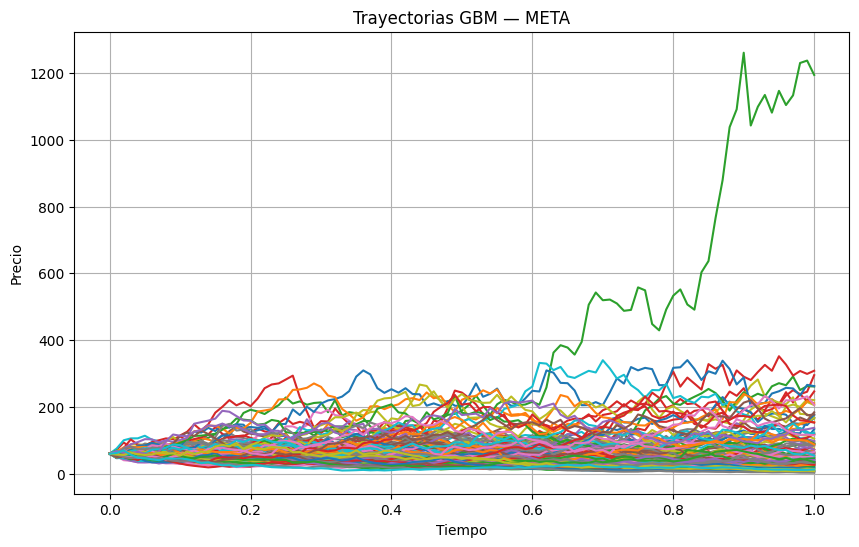

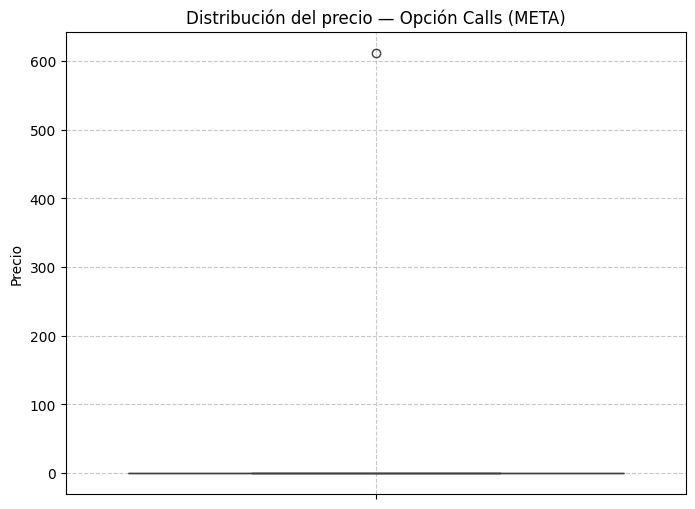

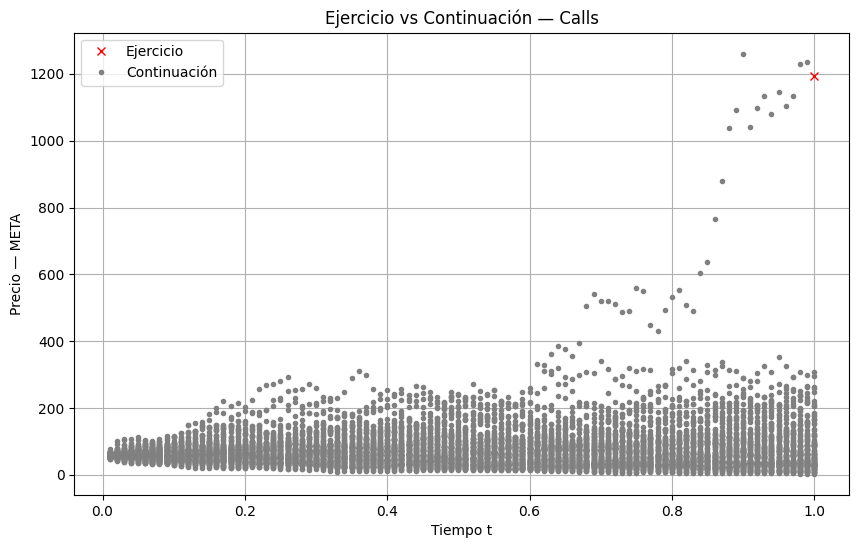

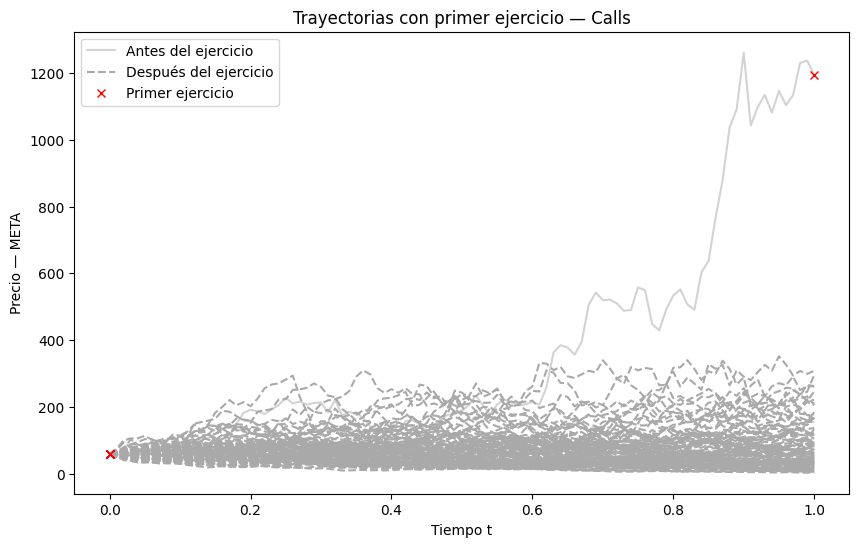

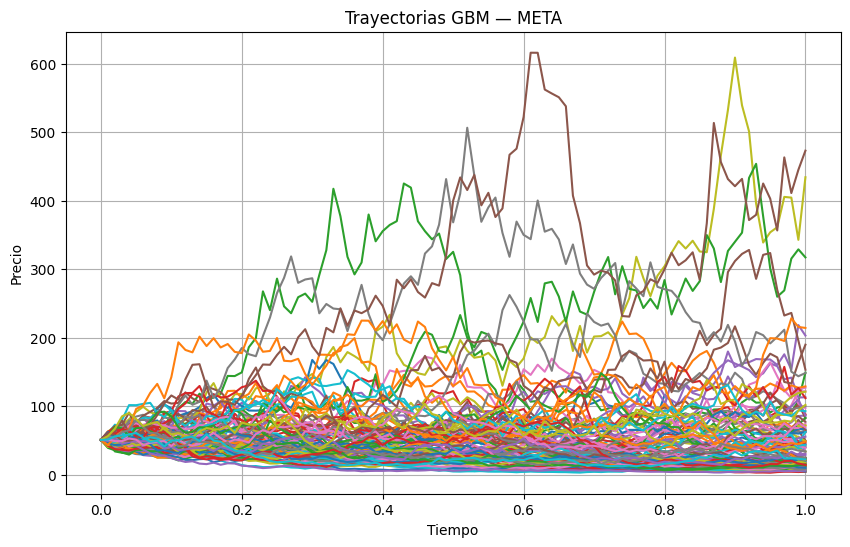

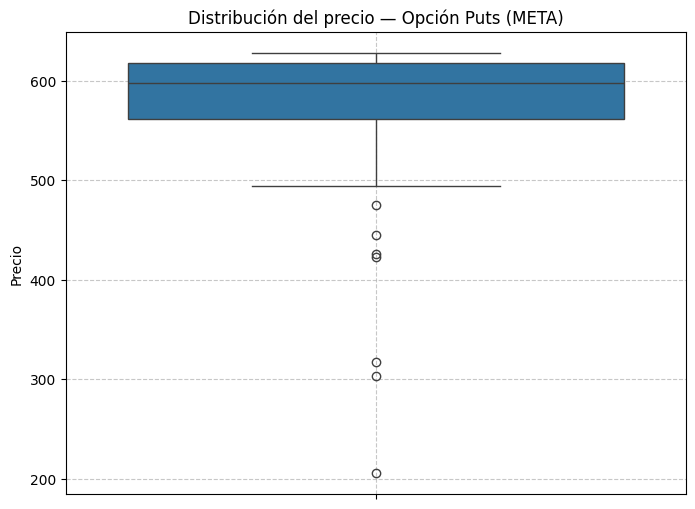

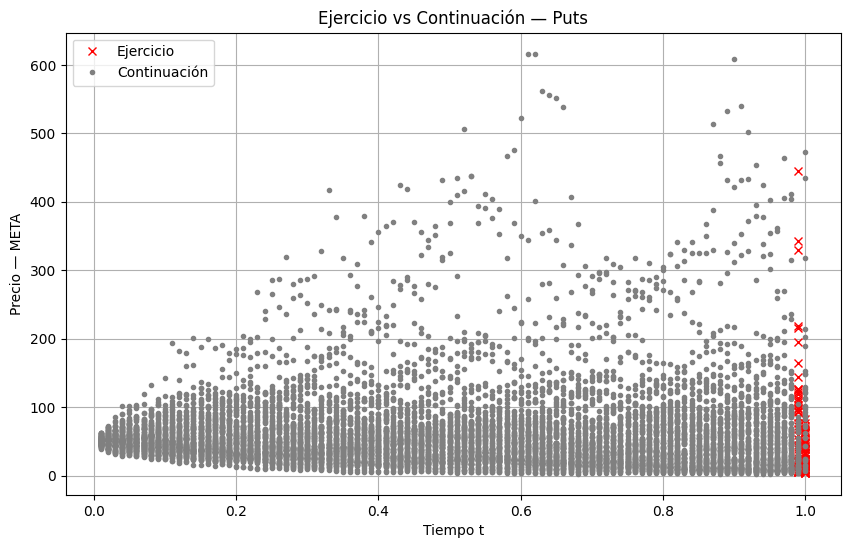

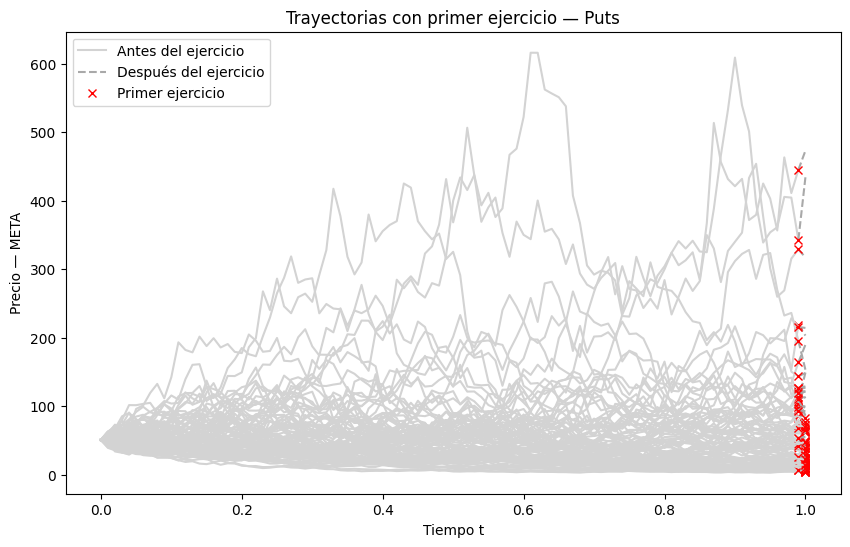

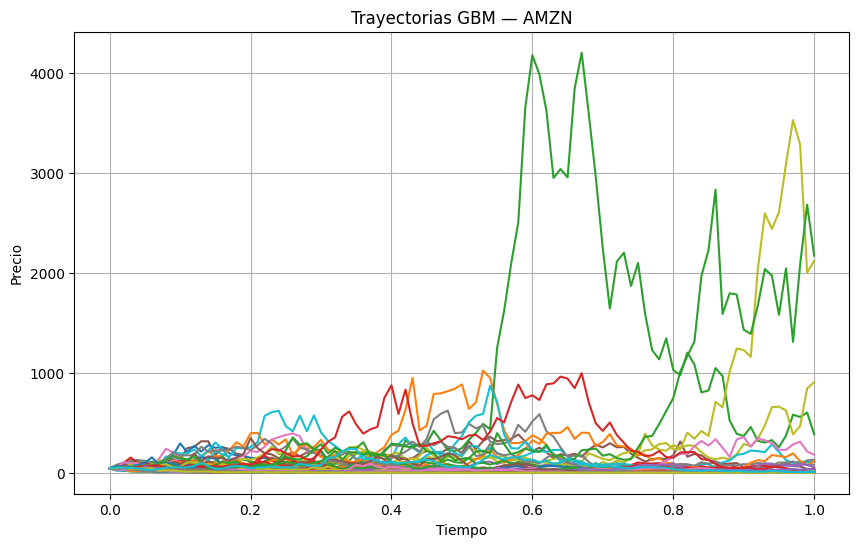

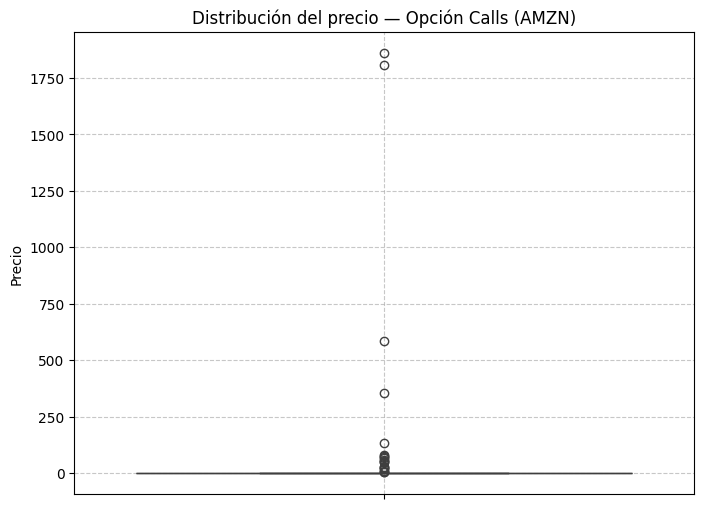

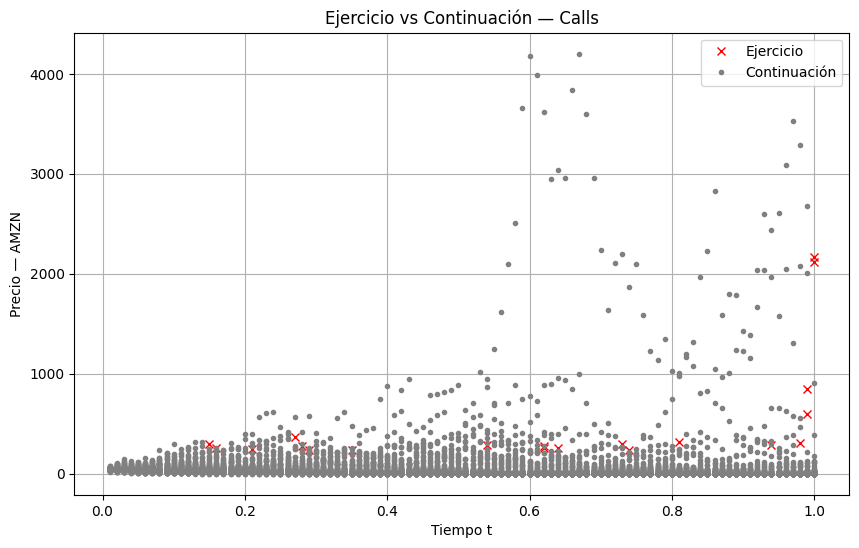

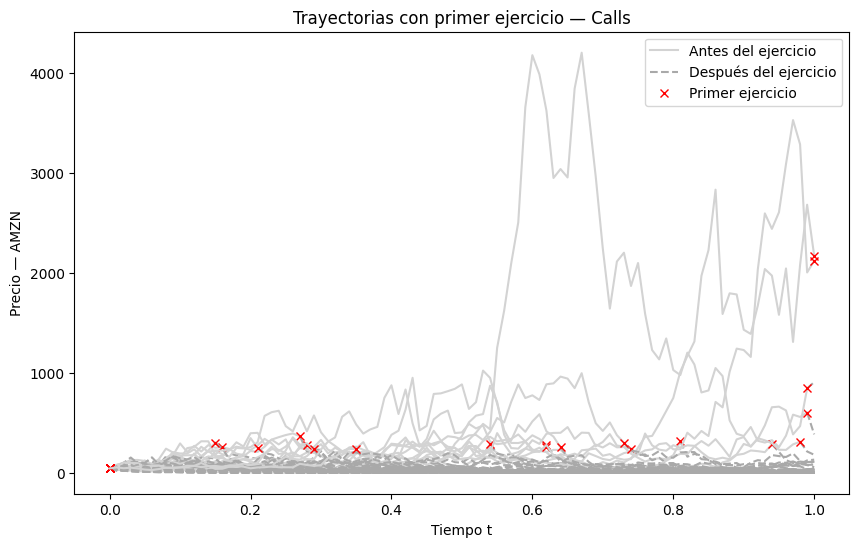

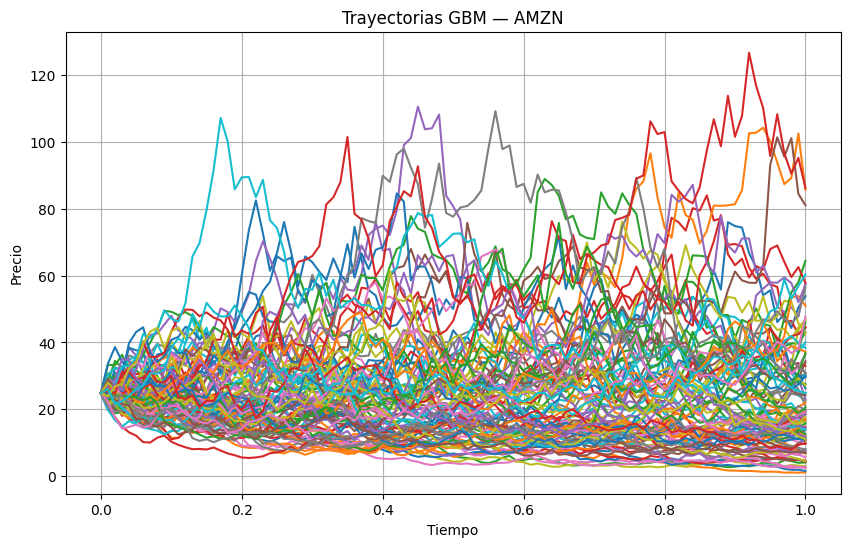

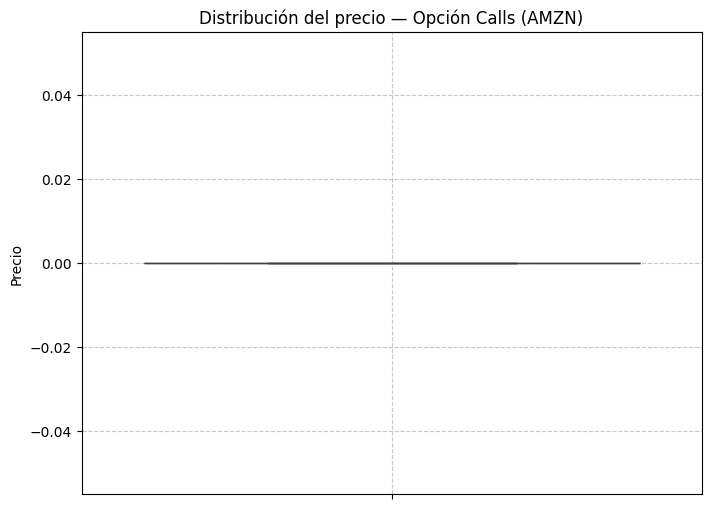

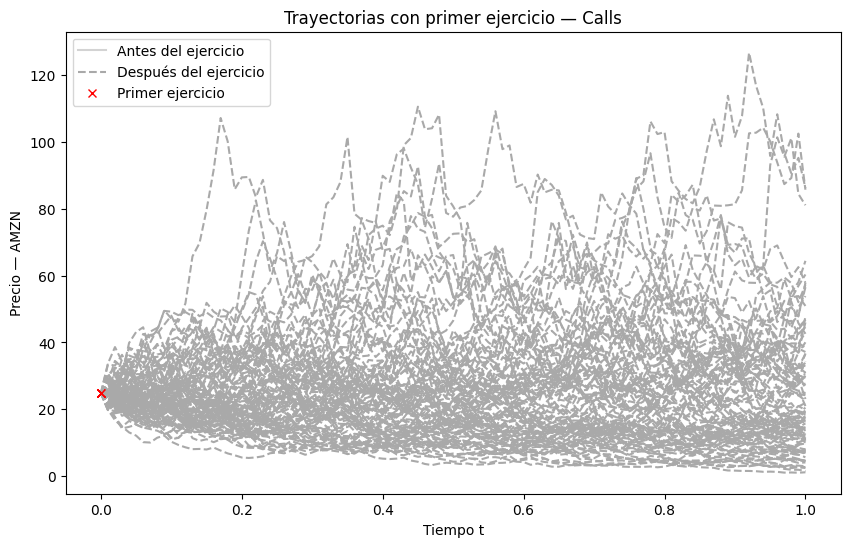

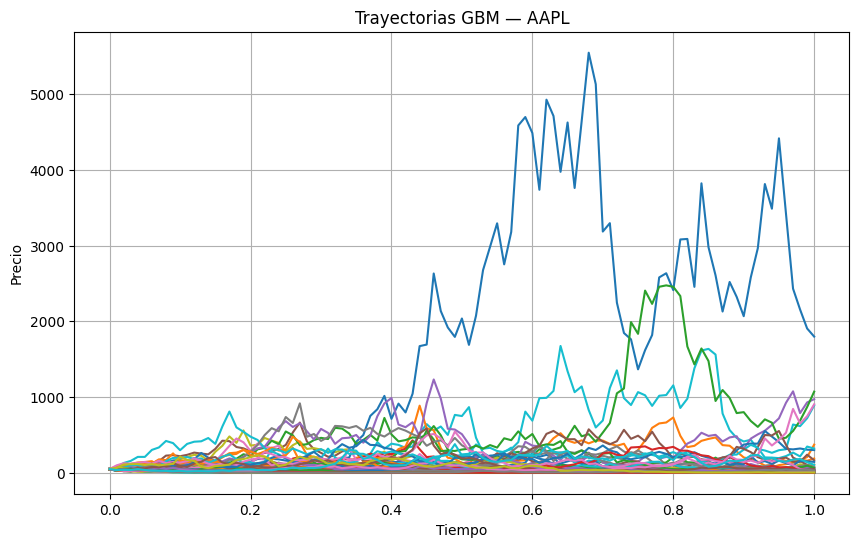

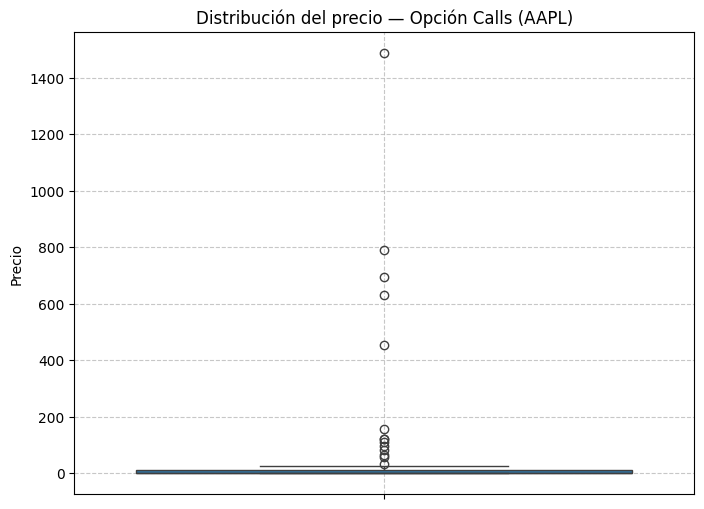

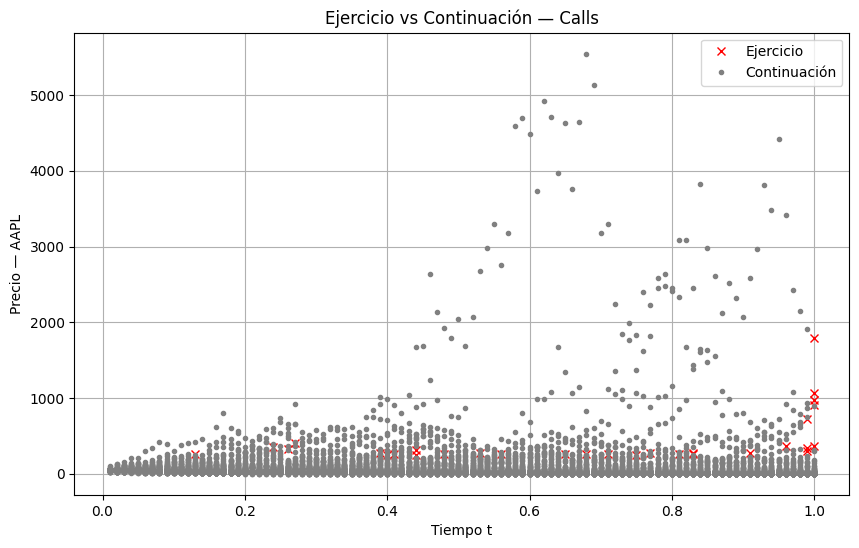

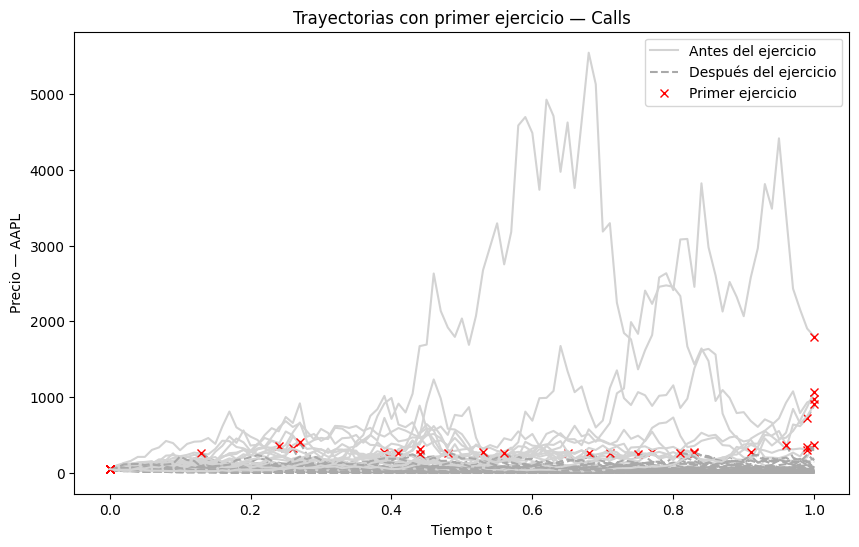

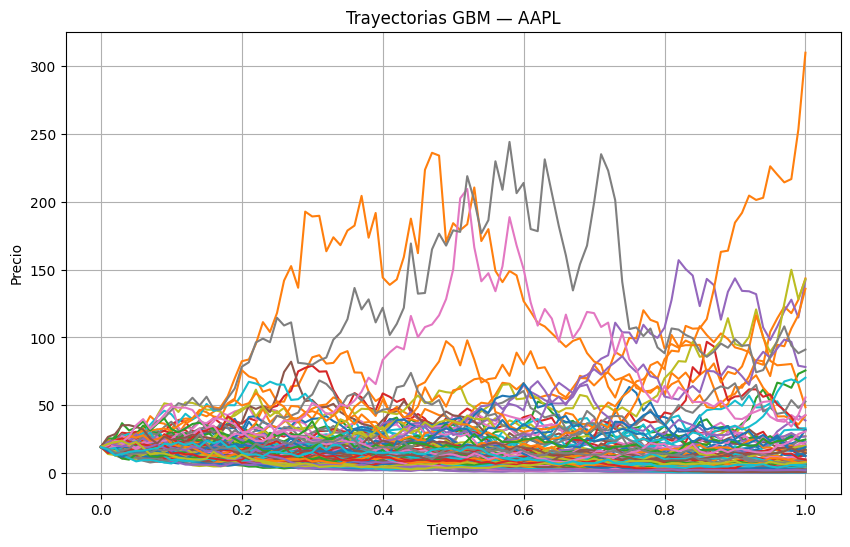

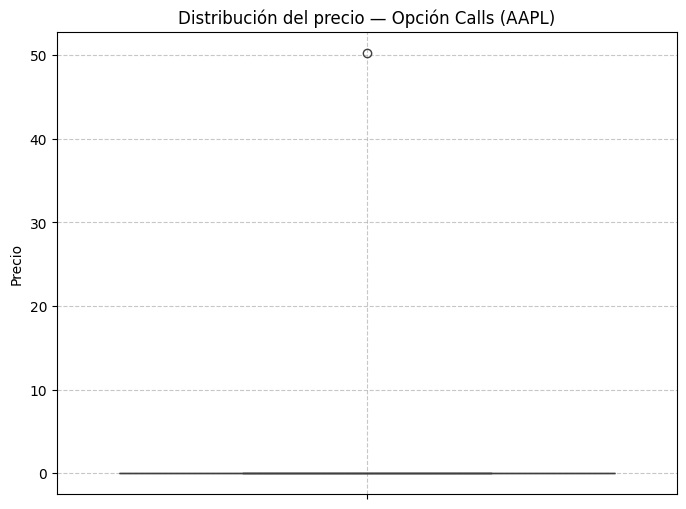

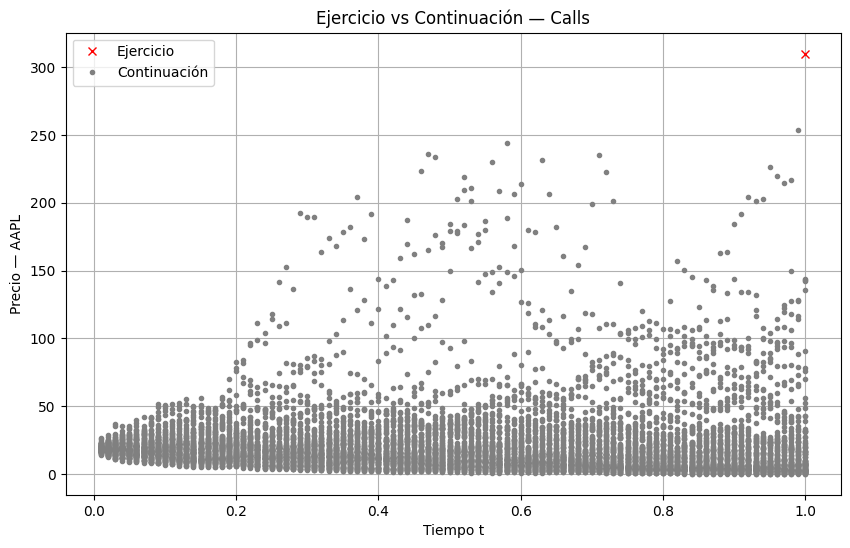

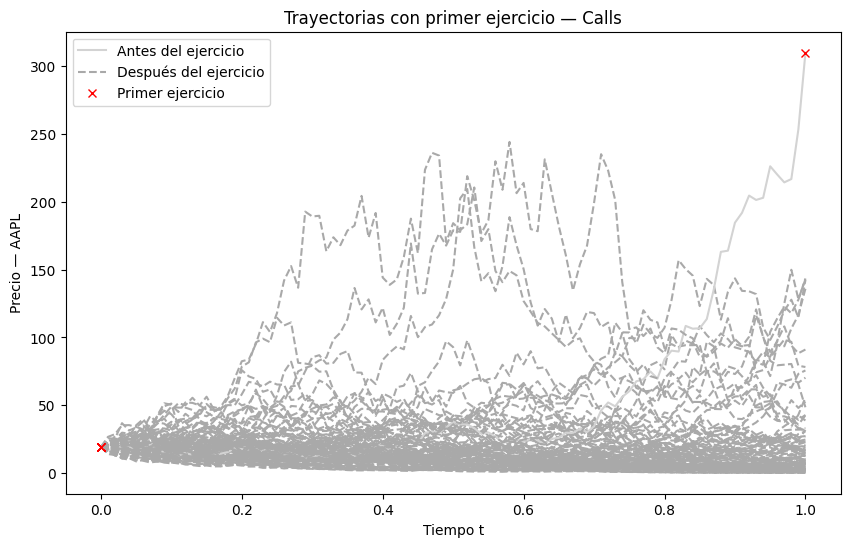

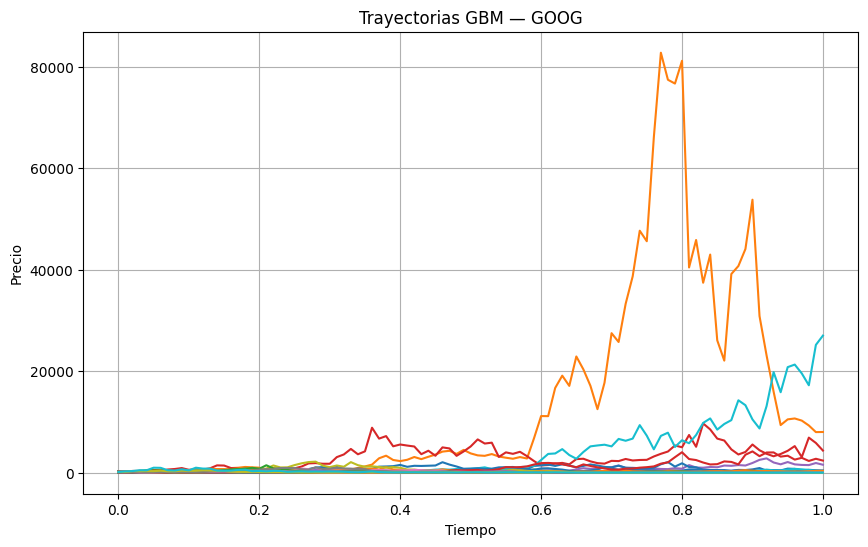

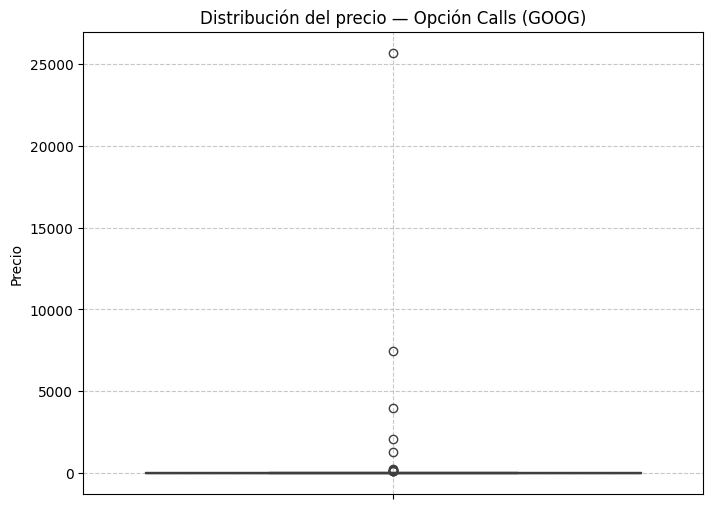

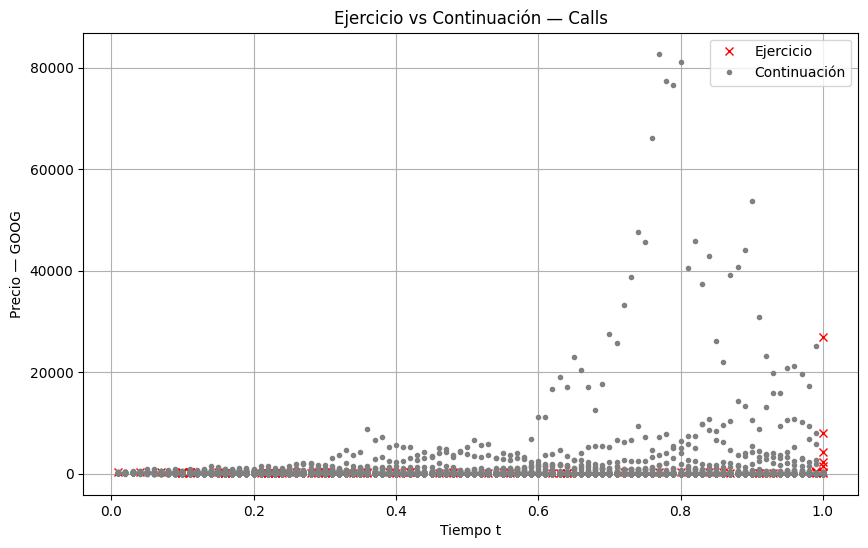

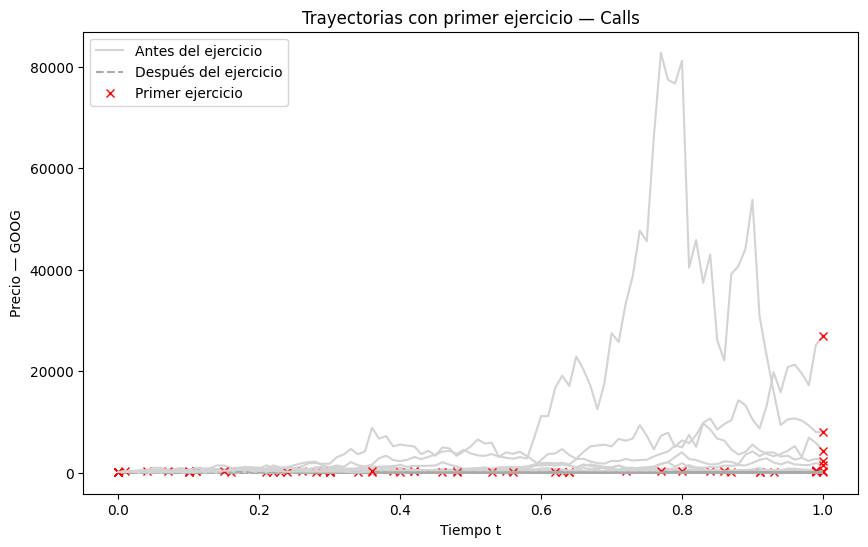

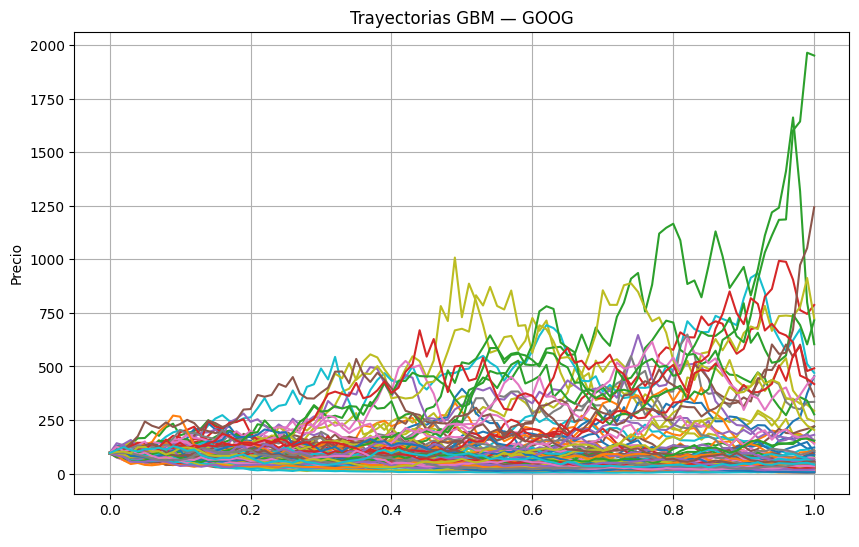

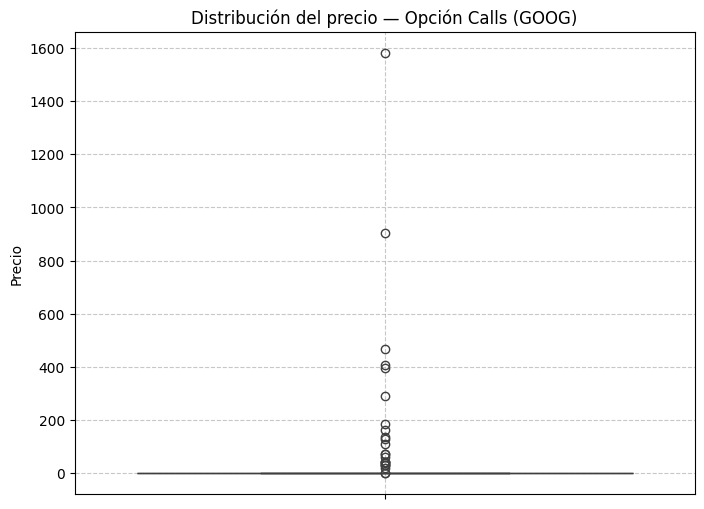

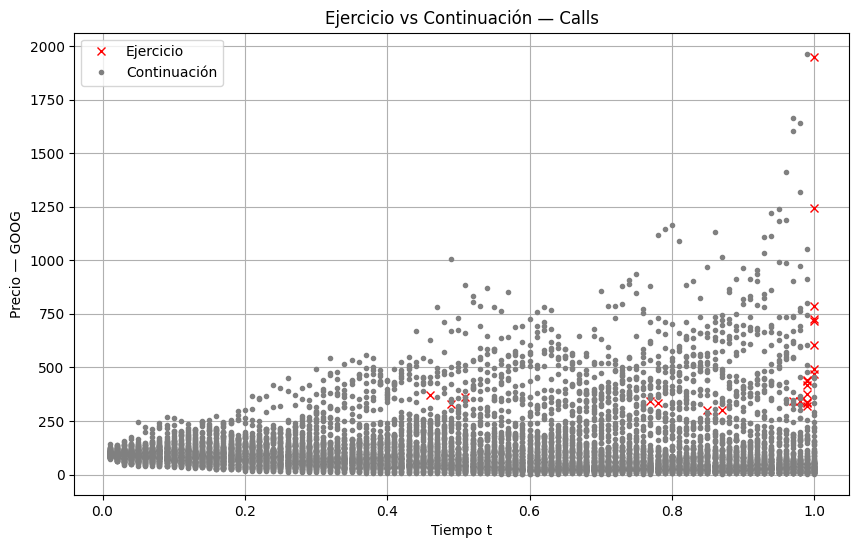

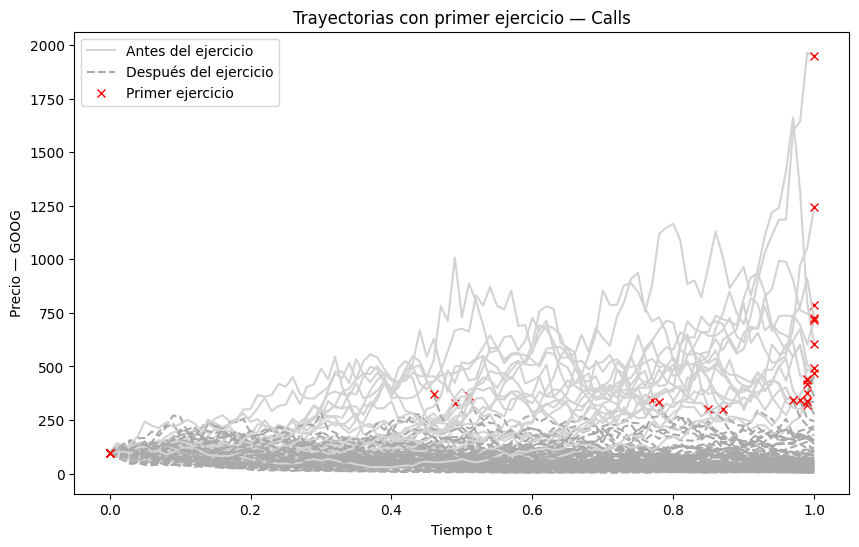

,contractSymbol,symbol,optionType,strike,impliedVolatility,optionPrice,lowerInterval,upperInterval,black_scholes_price,monte_carlo_price,binomial_price,lsp2_price,lsp3_price
5,META260511C00555000,META,calls,555.0,1.000982,6.115646,-5.870800,18.102091,0.841014,6.115646,0.000000,6.115646,6.115646
46,META260511P00660000,META,puts,660.0,1.195561,574.998726,561.301933,588.695520,582.228760,608.697488,659.999674,576.225256,576.187017
60,AMZN260511C00230000,AMZN,calls,230.0,2.682620,53.594307,1.603875,105.584740,27.202639,134.766530,0.000000,52.507204,50.180761
66,AMZN260511C00247500,AMZN,calls,247.5,1.023442,0.000000,0.000000,0.000000,0.341731,0.000000,0.000000,0.000000,0.000000
87,AAPL260511C00245000,AAPL,calls,245.0,2.492191,51.457794,13.307793,89.607795,28.127291,126.936987,0.000000,52.621878,48.666692
91,AAPL260511C00257500,AAPL,calls,257.5,1.318363,0.502538,-0.482419,1.487496,0.770758,0.502538,0.000000,0.502538,0.502538
117,GOOG260515C00205000,GOOG,calls,205.0,2.576175,433.502378,-94.297483,961.302239,110.205885,859.365719,0.000000,433.203851,449.044660
136,GOOG260515C00300000,GOOG,calls,300.0,1.325199,52.483427,14.124658,90.842196,22.047144,70.887879,0.000000,63.214617,59.391868


In [21]:
df['price_diff'] = df['optionPrice'] - df['monte_carlo_price']

contract_symbols = {}
for symbol in portfolio:
    sdf = df[df['symbol'] == symbol]
    max_row = sdf.loc[sdf['price_diff'].idxmax()]
    min_row = sdf.loc[sdf['price_diff'].idxmin()]
    contract_symbols[symbol] = {
        'max_contractSymbol': [max_row['contractSymbol']],
        'min_contractSymbol': [min_row['contractSymbol']]
    }

all_contracts = [
    c
    for v in contract_symbols.values()
    for lst in v.values()
    for c in lst
]

final_df = df[df['contractSymbol'].isin(all_contracts)].copy()

var_base = [
    'contractSymbol', 'lastTradeDate', 'strike', 'lastPrice',
    'impliedVolatility', 'optionType', 'symbol', 'shortDate', 'inTheMoney'
]
df_graficas = final_df[var_base].copy()

df_graficas['cashFlows'] = df_graficas.apply(
    lambda row: condicional(row['symbol'], row['optionType'], row['strike'], inf_portfolio),
    axis=1
)

df_graficas = agregar_valuaciones(
    df_graficas, T, dt, num_paths, rateRiskFree, inf_portfolio, graphics=True
)

df_graficas[cols_resultado]